# Proyecto de Análisis de Datos: Un fármaco contra el Alzheimer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import random
from scipy import stats

Generación de tabla de datos.
Se analizará la eficacia y el comportamiento de deserción para un medicamento con 2 grupos con dosis distintas y un grupo de contro (placebo).

In [2]:
# 1. Conectar a la base de datos
conexion = sqlite3.connect('ensayo_clinico.db')
cursor = conexion.cursor()

# 2. Habilitar el soporte de Llaves Foráneas en SQLite
cursor.execute("PRAGMA foreign_keys = ON;")

# 3. Crear la tabla: Cat_Dosis
cursor.execute("""
CREATE TABLE IF NOT EXISTS Cat_Dosis (
    id_dosis INTEGER PRIMARY KEY AUTOINCREMENT,
    nombre_dosis VARCHAR(50) NOT NULL,
    grupo VARCHAR(20) NOT NULL
);
""")

# 4. Crear la tabla: Pacientes
cursor.execute("""
CREATE TABLE IF NOT EXISTS pacientes (
    id_paciente INTEGER PRIMARY KEY,
    edad INTEGER NOT NULL,
    genero VARCHAR(20) NOT NULL,
    id_dosis INTEGER,
    estado_paciente VARCHAR(20) NOT NULL, -- 'Completado' o 'Deserción'
    FOREIGN KEY (id_dosis) REFERENCES Cat_Dosis(id_dosis)
);
""")

# 5. Crear la tabla: Resultados_Visitas
cursor.execute("""
CREATE TABLE IF NOT EXISTS Resultados_Visitas (
    id_visita INTEGER PRIMARY KEY AUTOINCREMENT,
    id_paciente INTEGER,
    numero_visita INTEGER NOT NULL,
    puntaje_mmse INTEGER,
    reporto_insomnio INTEGER,
    reporto_cefalea INTEGER,
    FOREIGN KEY (id_paciente) REFERENCES pacientes(id_paciente)
);
""")

# 7. Catálogo de dosis
dosis_catalogo = [
    (1, 'Placebo', 'Control'),
    (2, 'Dosis Baja (5mg)', 'Tratamiento'),
    (3, 'Dosis Alta (10mg)', 'Tratamiento')
]
cursor.executemany("INSERT INTO Cat_Dosis VALUES (?, ?, ?);", dosis_catalogo)

# 8. Listas para almacenar simulación masiva
lista_pacientes = []
lista_visitas = []
random.seed(42)

# Generación de 1,000 pacientes programáticamente
for i in range(1, 1001):
    id_p = 1000 + i
    edad = random.randint(60, 85) # Pacientes de la tercera edad
    genero = random.choice(['Femenino', 'Masculino'])
    id_dosis = random.choice([1, 2, 3]) # Asignación aleatoria de grupo

    # LÓGICA DE DESERCIÓN:
    # La dosis alta (3) provocará más deserciones por efectos secundarios (25% de probabilidad)
    if id_dosis == 3:
        estado = random.choices(['Completado', 'Deserción'], weights=[75, 25])[0]
    elif id_dosis == 2:
        estado = random.choices(['Completado', 'Deserción'], weights=[88, 12])[0]
    else: # Placebo
        estado = random.choices(['Completado', 'Deserción'], weights=[92, 8])[0]

    lista_pacientes.append((id_p, edad, genero, id_dosis, estado))

    # GENERACIÓN DE VISITAS TEMPORALES
    # Si completó, tiene 4 visitas. Si desertó, se sale aleatoriamente en la visita 2 o 3.
    max_visitas = 4
    if estado == 'Deserción':
        max_visitas = random.choice([2, 3])

    puntaje_inicial_mmse = random.randint(24, 28) # Deterioro cognitivo leve inicial

    for v in range(1, max_visitas + 1):
        # LÓGICA OCULTA DE EFICACIA (MMSE):
        # Si es Placebo (1), el puntaje decae rápido. Si es tratamiento, se mantiene estable.
        if id_dosis == 1:
            mmse = max(0, puntaje_inicial_mmse - (v - 1) * random.choice([1, 2]))
        else:
            mmse = max(0, puntaje_inicial_mmse - (v - 1) * random.choice([0, 1]))

        # Efectos secundarios aleatorios
        insomnio = random.choices([1, 0], weights=[22, 78])[0]
        cefalea = random.choices([1, 0], weights=[24, 76])[0]

        lista_visitas.append((id_p, v, mmse, insomnio, cefalea))

# 9. INSERCIÓN A SQL (Executemany)
cursor.executemany("INSERT INTO pacientes VALUES (?, ?, ?, ?, ?);", lista_pacientes)
cursor.executemany("INSERT INTO Resultados_Visitas (id_paciente, numero_visita, puntaje_mmse, reporto_insomnio, reporto_cefalea) VALUES (?, ?, ?, ?, ?);", lista_visitas)

conexion.commit()
conexion.close()

print(f"¡Base de datos poblada exitosamente! Se insertaron {len(lista_pacientes)} pacientes y {len(lista_visitas)} registros de visitas.")

¡Base de datos poblada exitosamente! Se insertaron 1000 pacientes y 3769 registros de visitas.


Número de pacientes por grupo de dosis.

In [3]:
conexion = sqlite3.connect('ensayo_clinico.db')

pacientes_dosis = """
SELECT d.nombre_dosis AS Dosis, COUNT(p.id_paciente) AS "Total de Pacientes"
FROM Pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
GROUP BY d.nombre_dosis;
"""
# -------------------------------------

df = pd.read_sql_query(pacientes_dosis, conexion)
conexion.close()
df

,Dosis,Total de Pacientes
0,Dosis Alta (10mg),361
1,Dosis Baja (5mg),317
2,Placebo,322


Evolución del deterioro cognitivo (puntaje mmse) dependiente de la dosis.

In [4]:
conexion = sqlite3.connect('ensayo_clinico.db')

eficacia = """
SELECT d.nombre_dosis AS Dosis, AVG(v.puntaje_mmse) AS "Promedio MMSE"
FROM pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
JOIN Resultados_Visitas v on p.id_paciente = v.id_paciente
GROUP BY nombre_dosis
"""
# -------------------------------------

df = pd.read_sql_query(eficacia, conexion)
conexion.close()
df

,Dosis,Promedio MMSE
0,Dosis Alta (10mg),25.290469
1,Dosis Baja (5mg),25.195851
2,Placebo,23.881643


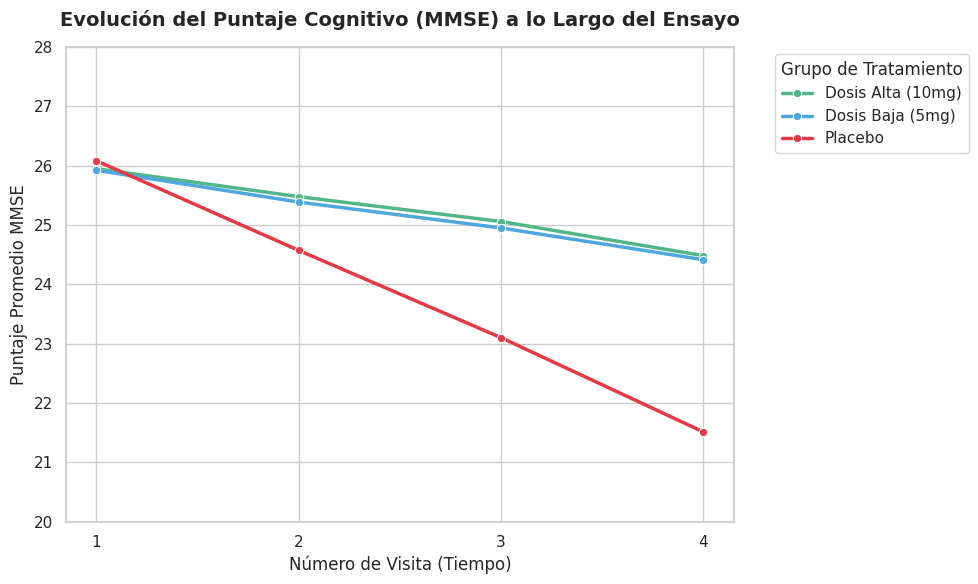

In [5]:
conexion = sqlite3.connect('ensayo_clinico.db')

query_evolucion = """
SELECT
    d.nombre_dosis AS Dosis,
    v.numero_visita AS Visita,
    AVG(v.puntaje_mmse) AS Promedio_MMSE
FROM Resultados_Visitas v
JOIN pacientes p ON v.id_paciente = p.id_paciente
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
GROUP BY d.nombre_dosis, v.numero_visita
ORDER BY d.nombre_dosis, v.numero_visita;
"""

df_evolucion = pd.read_sql_query(query_evolucion, conexion)
conexion.close()

# 1. Configurar el estilo de la gráfica usando Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Crear la gráfica de líneas
grafica = sns.lineplot(
    data=df_evolucion,
    x="Visita",
    y="Promedio_MMSE",
    hue="Dosis",
    marker="o",
    linewidth=2.5,
    palette={"Placebo": "#E63946", "Dosis Baja (5mg)": "#4EA8DE", "Dosis Alta (10mg)": "#52B788"}
)

# 3. Personalizar títulos y etiquetas
plt.title("Evolución del Puntaje Cognitivo (MMSE) a lo Largo del Ensayo", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Número de Visita (Tiempo)", fontsize=12)
plt.ylabel("Puntaje Promedio MMSE", fontsize=12)
plt.xticks([1, 2, 3, 4]) # Asegurar que solo muestre las visitas reales
plt.ylim(20, 28)         # Enfocar el rango del puntaje para notar el comportamiento

# 4. Colocar la leyenda de forma estética
plt.legend(title="Grupo de Tratamiento", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Análisis de significancia estadistica para la eficacia del medicamento en función de la dosis.

In [6]:
conexion = sqlite3.connect('ensayo_clinico.db')

query_anova = """
SELECT d.nombre_dosis AS Dosis, v.puntaje_mmse AS Puntaje_Final
FROM Resultados_Visitas v
JOIN Pacientes p ON v.id_paciente = p.id_paciente
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
WHERE v.numero_visita = 4;
"""

df_anova = pd.read_sql_query(query_anova, conexion)
conexion.close()

# 1. Separar los puntajes en arreglos independientes para cada grupo
placebo = df_anova[df_anova['Dosis'] == 'Placebo']['Puntaje_Final']
dosis_baja = df_anova[df_anova['Dosis'] == 'Dosis Baja (5mg)']['Puntaje_Final']
dosis_alta = df_anova[df_anova['Dosis'] == 'Dosis Alta (10mg)']['Puntaje_Final']

print("--- TAMAÑO DE MUESTRA EN VISITA 4 ---")
print(f"Placebo: {len(placebo)} pacientes")
print(f"Dosis Baja: {len(dosis_baja)} pacientes")
print(f"Dosis Alta: {len(dosis_alta)} pacientes\n" + "="*40 + "\n")

# 2. Ejecutar la prueba ANOVA de una vía
f_estadistico, p_valor = stats.f_oneway(placebo, dosis_baja, dosis_alta)

print(f"Estadístico F: {f_estadistico:.4f}")
print(f"Valor p (p-value): {p_valor:.4e}")

# 3. Conclusión
alpha = 0.05
print("\n--- CONCLUSIÓN DEL ANÁLISIS DE EFICACIA ---")
if p_valor < alpha:
    print("Diferencia Estadísticamente Significativa (Rechazamos H0)")
    print("El medicamento demostró un impacto real y significativo en el rendimiento cognitivo.")
    print("Las diferencias observadas en la Visita 4 no se deben al azar.")
else:
    print("No significativo (No se rechaza H0)")
    print("No se encontraron diferencias claras entre los tratamientos al final del ensayo.")

--- TAMAÑO DE MUESTRA EN VISITA 4 ---
Placebo: 292 pacientes
Dosis Baja: 278 pacientes
Dosis Alta: 286 pacientes

Estadístico F: 205.0801
Valor p (p-value): 1.8955e-73

--- CONCLUSIÓN DEL ANÁLISIS DE EFICACIA ---
✨ ¡Diferencia Estadísticamente Significativa! (Rechazamos H0)
El medicamento demostró un impacto real y significativo en el rendimiento cognitivo.
Las diferencias observadas en la Visita 4 no se deben al azar.


Análisis de la tasa de deserción en función de la dosis.

In [7]:
conexion = sqlite3.connect('ensayo_clinico.db')

query_desercion = """
SELECT
    d.nombre_dosis AS "Tipo de dosis",
    p.estado_paciente AS "Estado final",
    COUNT(p.id_paciente) AS "Total de pacientes",
    ROUND(COUNT(p.id_paciente) * 100.0 / SUM(COUNT(p.id_paciente)) OVER(PARTITION BY d.nombre_dosis), 2) || '%' AS "Porcentaje de grupo"
FROM Pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
GROUP BY d.nombre_dosis, p.estado_paciente;
"""

df_desercion = pd.read_sql_query(query_desercion, conexion)
conexion.close()

df_desercion

,Tipo de dosis,Estado final,Total de pacientes,Porcentaje de grupo
0,Dosis Alta (10mg),Completado,286,79.22%
1,Dosis Alta (10mg),Deserción,75,20.78%
2,Dosis Baja (5mg),Completado,278,87.7%
3,Dosis Baja (5mg),Deserción,39,12.3%
4,Placebo,Completado,292,90.68%
5,Placebo,Deserción,30,9.32%


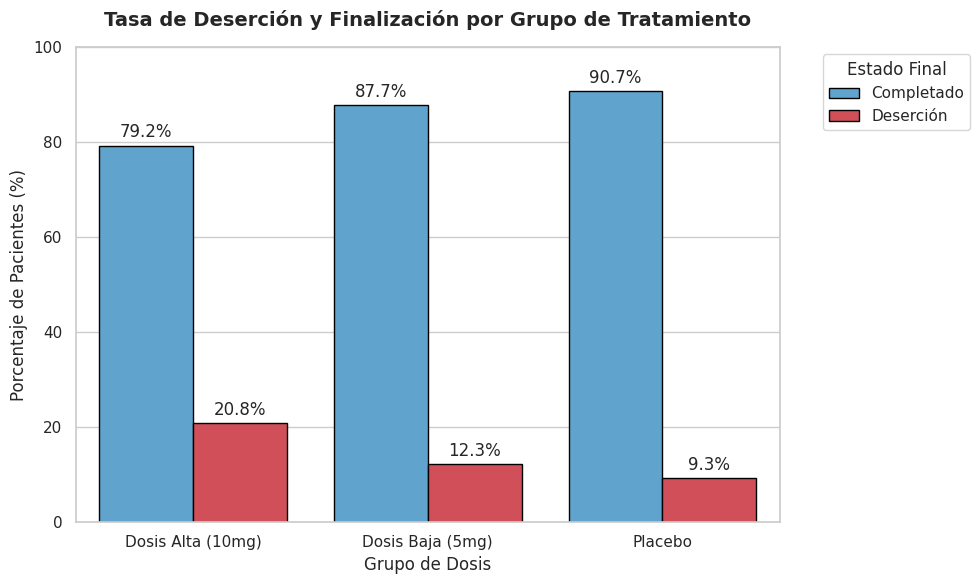

In [8]:
conexion = sqlite3.connect('ensayo_clinico.db')

# 1. Query simple para obtener los conteos brutos
query_base_desercion = """
SELECT
    d.nombre_dosis AS Dosis,
    p.estado_paciente AS Estado
FROM pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis;
"""

df_base = pd.read_sql_query(query_base_desercion, conexion)
conexion.close()

# 2. TRANSFORMAR DATOS CON PANDAS
# Creamos la tabla de contingencia y calculamos porcentajes por fila (axis=0)
tabla_pct = pd.crosstab(df_base['Dosis'], df_base['Estado'], normalize='index') * 100
tabla_pct = tabla_pct.reset_index() # Convertir el índice en columna

# Transformar a formato "largo" para Seaborn (Melt)
df_plot = tabla_pct.melt(id_vars='Dosis', var_name='Estado Final', value_name='Porcentaje')

# 3. GENERAR LA VISUALIZACIÓN
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Crear gráfica de barras agrupadas
grafica = sns.barplot(
    data=df_plot,
    x="Dosis",
    y="Porcentaje",
    hue="Estado Final",
    palette={'Completado': '#4EA8DE', 'Deserción': '#E63946'}, # Colores consistentes
    edgecolor="black",
    linewidth=1
)

# 4. SUTILEZAS DE DISEÑO PROFESIONAL
# Título claro y etiquetas bonitas (sin guiones bajos)
plt.title("Tasa de Deserción y Finalización por Grupo de Tratamiento", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Grupo de Dosis", fontsize=12)
plt.ylabel("Porcentaje de Pacientes (%)", fontsize=12)
plt.ylim(0, 100) # El eje Y siempre debe llegar a 100 para dar contexto

# Agregar etiquetas de porcentaje sobre cada barra
for container in grafica.containers:
    grafica.bar_label(container, fmt='%.1f%%', padding=3)

# Mover la leyenda afuera para no estorbar
plt.legend(title="Estado Final", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Análisis de significancia estadistica para la deserción de los pacientes en función de la dosis.

In [9]:
# 1. Extraer la combinación de dosis y estado de cada paciente
conexion = sqlite3.connect('ensayo_clinico.db')

query_chi = """
SELECT d.nombre_dosis, p.estado_paciente
FROM Pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis;
"""

df_chi = pd.read_sql_query(query_chi, conexion)
conexion.close()

# 2. Construir la Tabla de Contingencia (Cruzar las dos variables en una matriz)
tabla_contingencia = pd.crosstab(df_chi['nombre_dosis'], df_chi['estado_paciente'])

print("--- TABLA DE CONTINGENCIA OBSERVADA ---")
print(tabla_contingencia)
print("\n" + "="*40 + "\n")

# 3. Ejecutar la prueba Chi-Cuadrado
chi2, p_valor, dof, esperados = stats.chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi-Cuadrado: {chi2:.4f}")
print(f"Valor p (p-value): {p_valor:.4e}") # Notación científica para valores muy pequeños

# 4. Interpretación formal de los resultados
alpha = 0.05
print("\n--- CONCLUSIÓN ESTADÍSTICA ---")
if p_valor < alpha:
    print("Resultado Estadísticamente Significativo (Rechazamos la Hipótesis Nula)")
    print("Hay evidencia matemática suficiente para afirmar que el tipo de dosis SÍ está asociado con la tasa de deserción de los pacientes.")
else:
    print("No significativo (No se rechaza la Hipótesis Nula)")
    print("La diferencia en la deserción se debe probablemente al azar; no hay asociación clara entre la dosis y el abandono.")

--- TABLA DE CONTINGENCIA OBSERVADA ---
estado_paciente    Completado  Deserción
nombre_dosis                            
Dosis Alta (10mg)         286         75
Dosis Baja (5mg)          278         39
Placebo                   292         30


Estadístico Chi-Cuadrado: 19.7856
Valor p (p-value): 5.0537e-05

--- CONCLUSIÓN ESTADÍSTICA ---
✨ ¡Resultado Estadísticamente Significativo! (Rechazamos la Hipótesis Nula)
Hay evidencia matemática suficiente para afirmar que el tipo de dosis SÍ está asociado con la tasa de deserción de los pacientes.


¿Es esta deseción causada por los efectos secundarios del medicamento?

In [10]:
conexion = sqlite3.connect('ensayo_clinico.db')

efectos_secundarios = """
SELECT d.nombre_dosis AS Dosis, SUM(v.reporto_insomnio) AS "Casos de Insomnio", SUM(v.reporto_cefalea) AS "Casos de Cefalea"
FROM pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
JOIN Resultados_Visitas v on p.id_paciente = v.id_paciente
GROUP BY nombre_dosis
"""
# -------------------------------------

df = pd.read_sql_query(efectos_secundarios, conexion)
conexion.close()
df

,Dosis,Casos de Insomnio,Casos de Cefalea
0,Dosis Alta (10mg),297,312
1,Dosis Baja (5mg),284,296
2,Placebo,278,306


Extracción de datos en Excel para su uso en Tableau

In [11]:
conexion = sqlite3.connect('ensayo_clinico.db')

# --- TABLA 1: Detalle completo de pacientes y visitas
query_tableau = """
SELECT
    p.id_paciente AS "ID Paciente",
    p.genero AS "Género",
    p.edad AS "Edad",
    p.estado_paciente AS "Estado Final",
    d.nombre_dosis AS "Tipo de Dosis",
    v.numero_visita AS "Número de Visita",
    v.puntaje_mmse AS "Puntaje MMSE",
    v.reporto_insomnio AS "Reportó Insomnio",
    v.reporto_cefalea AS "Reportó Cefalea"
FROM Resultados_Visitas v
JOIN Pacientes p ON v.id_paciente = p.id_paciente
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
ORDER BY p.id_paciente, v.numero_visita;
"""

# --- TABLA 2: RESUMEN DE INDICADORES (KPIs agregados por dosis) ---
query_kpis = """
SELECT
    d.nombre_dosis AS "Tipo de Dosis",
    COUNT(DISTINCT p.id_paciente) AS "Total Pacientes Inscritos",
    ROUND(AVG(CASE WHEN v.numero_visita = 4 THEN v.puntaje_mmse END), 2) AS "MMSE Promedio Final",
    SUM(v.reporto_insomnio) AS "Total Casos Insomnio",
    SUM(v.reporto_cefalea) AS "Total Casos Cefalea"
FROM Pacientes p
JOIN Cat_Dosis d ON p.id_dosis = d.id_dosis
LEFT JOIN Resultados_Visitas v ON p.id_paciente = v.id_paciente
GROUP BY d.nombre_dosis;
"""

# 2. Cargar los resultados en DataFrames de Pandas
df_master_tableau = pd.read_sql_query(query_tableau, conexion)
df_resumen_kpis = pd.read_sql_query(query_kpis, conexion)

# 3. Cerrar la conexión
conexion.close()

# 4. Guardar en múltiples pestañas de un solo Excel
nombre_excel = "Resultados_Ensayo_Clinico.xlsx"

# Iniciamos el escritor de Excel usando el motor de openpyxl
with pd.ExcelWriter(nombre_excel, engine='openpyxl') as writer:
    # Pestaña 1: Datos planos para Tableau
    df_master_tableau.to_excel(writer, sheet_name='Datos_Para_Tableau', index=False)

    # Pestaña 2: Resumen rápido de KPIs
    df_resumen_kpis.to_excel(writer, sheet_name='KPIs_Globales', index=False)

print(f"¡Éxito total! El archivo '{nombre_excel}' ha sido generado.")

¡Éxito total! El archivo 'Resultados_Ensayo_Clinico.xlsx' ha sido generado.


In [12]:
conexion = sqlite3.connect('ensayo_clinico.db')

with pd.ExcelWriter("Base_Ensayo_Clinico_Relacional.xlsx", engine='openpyxl') as writer:
    pd.read_sql_query("SELECT * FROM Pacientes", conexion).to_excel(writer, sheet_name='Pacientes', index=False)
    pd.read_sql_query("SELECT * FROM Cat_Dosis", conexion).to_excel(writer, sheet_name='Cat_Dosis', index=False)
    pd.read_sql_query("SELECT * FROM Resultados_Visitas", conexion).to_excel(writer, sheet_name='Resultados_Visitas', index=False)

conexion.close()